# Consumo doméstico de café — Análisis exploratorio

**Reto técnico NTT Data — High Garden Coffee**

Este notebook cubre el primer requisito del enunciado: *análisis de la información*.

La lógica de carga y limpieza **no vive aquí**. Vive en `src/coffee/data.py`, que es
código testeable y reutilizable. Este notebook la importa y se dedica a lo que un
notebook hace bien: explorar, graficar y contar la historia.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from coffee.data import load_raw, load_clean, year_columns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

FIGS = Path.cwd().parent / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

## 1. El dato crudo

55 filas, 33 columnas. Formato ancho: una fila por país, una columna por año cafetero.

In [2]:
raw = load_raw()
print(f"Dimensiones: {raw.shape[0]} filas x {raw.shape[1]} columnas")
print(f"Países únicos: {raw.Country.nunique()}")
print(f"Nulos: {raw.isna().sum().sum()}")
raw.head(3)

Dimensiones: 55 filas x 33 columnas
Países únicos: 55
Nulos: 0


,Country,Coffee type,1990/91,1991/92,1992/93,1993/94,1994/95,1995/96,1996/97,1997/98,1998/99,1999/00,2000/01,2001/02,2002/03,2003/04,2004/05,2005/06,2006/07,2007/08,2008/09,2009/10,2010/11,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,Total_domestic_consumption
0,Angola,Robusta/Arabica,1200000,1800000,2100000,1200000,1500000,600000,1200000,2400000,1800000,1200000,1200000,1200000,1200000,900000,900000,900000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,46500000
1,Bolivia (Plurinational State of),Arabica,1500000,1620000,1650000,1710000,1770000,1830000,1890000,1950000,1980000,2040000,2100000,2190000,2250000,2310000,2700000,2460000,2520000,2610000,2700000,2760000,2850000,2940000,3030000,3120000,3210000,3300000,3420000,3510000,3600000,3660000,75180000
2,Brazil,Arabica/Robusta,492000000,510000000,534000000,546000000,558000000,606000000,660000000,690000000,732000000,762000000,792000000,815400000,825000000,852000000,896760000,932280000,979860000,1026600000,1059600000,1103400000,1147920000,1183200000,1219800000,1205100000,1219980000,1230480000,1273500000,1319820000,1332000000,1320000000,27824700000


### Las unidades no son tazas

El enunciado dice que el consumo está *"en tazas"*. Es falso, y vale la pena demostrarlo
en vez de afirmarlo.

Brasil aparece con 492,000,000 en 1990/91. La ICO (International Coffee Organization,
fuente original de estos datos) reporta para ese año **8,200 miles de sacos de 60 kg**.

Si la unidad fueran kilogramos derivados de sacos, se cumpliría que
`8,200 x 60,000 = 492,000,000`. La verificación es directa.

In [3]:
brasil_90 = raw.loc[raw.Country == "Brazil", "1990/91"].iloc[0]
print(f"Brasil 1990/91 en el dataset : {brasil_90:,}")
print(f"ICO: 8,200 miles de sacos x 60,000 = {8200 * 60_000:,}")
print(f"¿Coinciden? {brasil_90 == 8200 * 60_000}")

# Si el origen son sacos de 60 kg, casi todos los valores deben ser divisibles por 60
valores = raw[year_columns(raw)].values.ravel()
print(f"\nValores divisibles por 60: {100 * np.mean(valores % 60 == 0):.1f}%")

Brasil 1990/91 en el dataset : 492,000,000
ICO: 8,200 miles de sacos x 60,000 = 492,000,000
¿Coinciden? True

Valores divisibles por 60: 99.9%


**Conclusión:** la unidad es **kilogramos**, derivada de miles de sacos de 60 kg.

Esto importa para el negocio: un error de unidades se propaga a toda la capa de precios
y de volumen. Queda documentado, y la serie se expone también en sacos de 60 kg,
que es la unidad estándar de la industria cafetera.

## 2. Calidad del dato: los ceros no son ceros

Antes de limpiar, hay que entender *qué* se está limpiando. El mapa siguiente muestra
dónde están los ceros: cada fila es un país, cada columna un año.

In [4]:
years = year_columns(raw)
print("                          " + "".join(str(i % 10) for i in range(30)))
for _, r in raw.iterrows():
    patron = "".join("0" if r[y] == 0 else "." for y in years)
    if "0" in patron:
        print(f"{r.Country[:24]:26}{patron}")

                          012345678901234567890123456789
Timor-Leste               00000000000000000000..........
Zambia                    ...................00000000000
Equatorial Guinea         000000000000000000000000000000
Guyana                    00000000......................
Lao People's Democratic   000000000000..................
Nepal                     000000000000000000000000000000
Yemen                     0000000000000.................


Los ceros están en **bloques contiguos**, no dispersos. Eso descarta que sean errores
aleatorios y revela tres casos distintos:

| Caso | Países | Interpretación |
|---|---|---|
| Ceros al **inicio** | Timor-Leste, Yemen, Laos, Guyana | El país empezó a reportar tarde. Timor-Leste se independizó en 2002. |
| Ceros al **final** | Zambia | Dejó de reportar a la ICO. **Caso peligroso.** |
| Todo en ceros | Nepal, Guinea Ecuatorial | Sin información. |

Zambia es el caso crítico: 19 años de datos y luego 11 ceros. Si se dejan tal cual,
cualquier modelo aprende que Zambia consume cero café para siempre. Es el tipo de error
que no revienta el código pero sí el resultado.

### Series imputadas con constantes

Otro problema, menos visible: países con 2 o 3 valores distintos en 30 años.
Eso no es consumo medido, es relleno.

In [5]:
nun = raw[years].nunique(axis=1)
sospechosas = raw.loc[nun <= 3, ["Country"]].copy()
sospechosas["valores_distintos"] = nun[nun <= 3]
sospechosas["min"] = raw.loc[nun <= 3, years].min(axis=1)
sospechosas["max"] = raw.loc[nun <= 3, years].max(axis=1)
sospechosas.sort_values("valores_distintos")

,Country,valores_distintos,min,max
28,Equatorial Guinea,1,0,0
42,Nepal,1,0,0
7,Malawi,2,60000,120000
9,Paraguay,2,900000,1200000
12,Timor-Leste,2,0,29400
14,Congo,2,160020,180000
26,Democratic Republic of Congo,2,11880000,12000000
40,Liberia,2,180000,300000
25,Côte d'Ivoire,3,3000000,19020000
44,Nigeria,3,1650000,2400000


**Por qué importa para la evaluación del modelo:** un modelo *naive* (repetir el último
valor) acierta estas series casi perfecto. Si entran al conjunto de prueba, las métricas
salen excelentes por la razón equivocada. Se marcan con `is_low_variance` y se excluyen
del backtesting.

## 3. El dataset limpio

Se aplican las políticas declaradas en `src/coffee/data.py`.

In [6]:
df, reporte = load_clean()

print(f"Filas: {len(df):,} | Países: {df.country.nunique()} | Años: {df.year.min()}-{df.year.max()}\n")
for k, v in reporte.items():
    print(f"{k:22} {v}")

aptos = df[df.forecastable & ~df.is_low_variance].country.nunique()
print(f"\nPaíses aptos para modelar: {aptos}")

Filas: 1,526 | Países: 53 | Años: 1990-2019

dropped_all_zero       ['Equatorial Guinea', 'Nepal']
truncated_leading      {'Guyana': 8, "Lao People's Democratic Republic": 12, 'Timor-Leste': 20, 'Yemen': 13}
truncated_trailing     {'Zambia': 11}
low_variance           ['Congo', "Côte d'Ivoire", 'Democratic Republic of Congo', 'Liberia', 'Malawi', 'Nigeria', 'Paraguay', 'Sierra Leone', 'Timor-Leste']
not_forecastable       ['Zambia']

Países aptos para modelar: 43


In [7]:
df.head()

,country,coffee_type,crop_year,consumption_kg,year,primary_type,is_blend,forecastable,is_low_variance,consumption_bags_60kg
0,Angola,Robusta/Arabica,1990/91,1200000,1990,Robusta,True,True,False,20000.0
1,Angola,Robusta/Arabica,1991/92,1800000,1991,Robusta,True,True,False,30000.0
2,Angola,Robusta/Arabica,1992/93,2100000,1992,Robusta,True,True,False,35000.0
3,Angola,Robusta/Arabica,1993/94,1200000,1993,Robusta,True,True,False,20000.0
4,Angola,Robusta/Arabica,1994/95,1500000,1994,Robusta,True,True,False,25000.0


## 4. Panorama mundial

Primera pregunta de negocio: ¿el mercado crece?

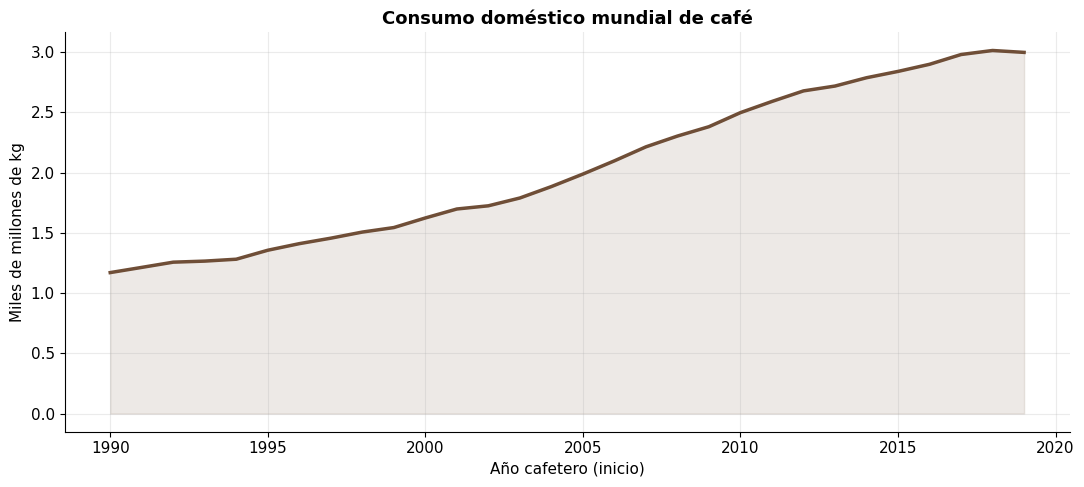

1990: 1.17  ->  2019: 3.00 miles de millones de kg
Crecimiento acumulado: 156%
CAGR: 3.30% anual


In [8]:
mundial = df.groupby("year").consumption_kg.sum() / 1e9

fig, ax = plt.subplots()
ax.plot(mundial.index, mundial.values, lw=2.5, color="#6F4E37")
ax.fill_between(mundial.index, mundial.values, alpha=0.12, color="#6F4E37")
ax.set_title("Consumo doméstico mundial de café", fontsize=13, weight="bold")
ax.set_ylabel("Miles de millones de kg")
ax.set_xlabel("Año cafetero (inicio)")
fig.tight_layout()
fig.savefig(FIGS / "01_consumo_mundial.png", dpi=150)
plt.show()

cagr_mundial = (mundial.iloc[-1] / mundial.iloc[0]) ** (1 / 29) - 1
print(f"1990: {mundial.iloc[0]:.2f}  ->  2019: {mundial.iloc[-1]:.2f} miles de millones de kg")
print(f"Crecimiento acumulado: {100 * (mundial.iloc[-1] / mundial.iloc[0] - 1):.0f}%")
print(f"CAGR: {100 * cagr_mundial:.2f}% anual")

El mercado **creció 156% en 30 años**, a una tasa compuesta de 3.3% anual. Es un mercado
en expansión sostenida, sin quiebres estructurales visibles. Para una exportadora eso es
buena noticia de fondo, pero el promedio esconde lo importante: *dónde* está creciendo.

## 5. Concentración: el mercado es Brasil y seis más

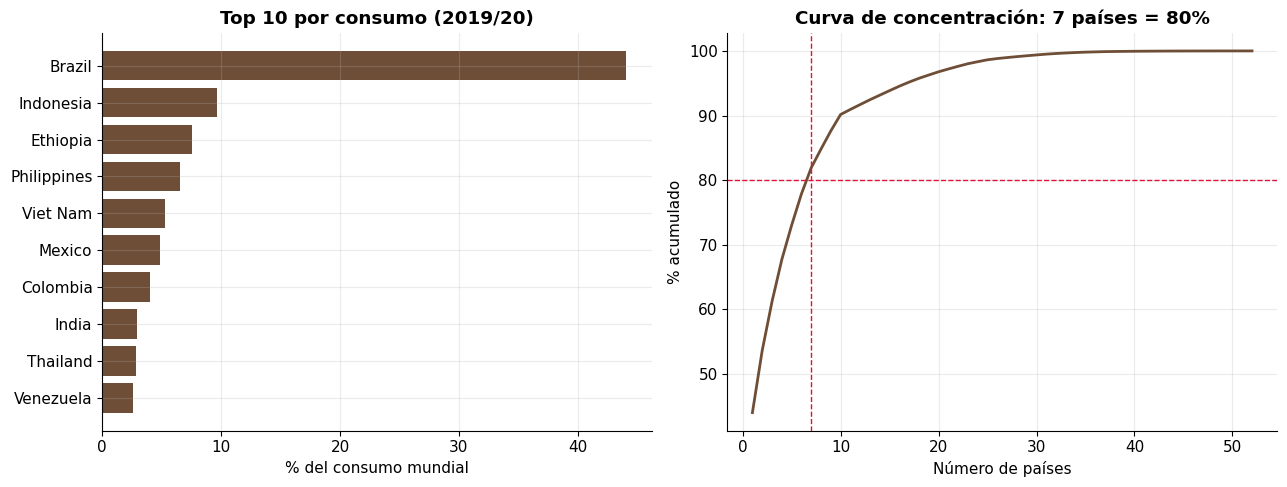

Brasil solo: 44.0% del consumo mundial
Top 5: 73.0%  |  Top 10: 90.2%


In [9]:
c2019 = df[df.year == 2019].groupby("country").consumption_kg.sum().sort_values(ascending=False)
share = 100 * c2019 / c2019.sum()
cum = share.cumsum()
n80 = int((cum < 80).sum()) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

top = share.head(10)[::-1]
ax1.barh(top.index, top.values, color="#6F4E37")
ax1.set_title("Top 10 por consumo (2019/20)", weight="bold")
ax1.set_xlabel("% del consumo mundial")

ax2.plot(range(1, len(cum) + 1), cum.values, lw=2, color="#6F4E37")
ax2.axhline(80, ls="--", color="crimson", lw=1)
ax2.axvline(n80, ls="--", color="crimson", lw=1)
ax2.set_title(f"Curva de concentración: {n80} países = 80%", weight="bold")
ax2.set_xlabel("Número de países")
ax2.set_ylabel("% acumulado")

fig.tight_layout()
fig.savefig(FIGS / "02_concentracion.png", dpi=150)
plt.show()

print(f"Brasil solo: {share.iloc[0]:.1f}% del consumo mundial")
print(f"Top 5: {share.head(5).sum():.1f}%  |  Top 10: {share.head(10).sum():.1f}%")

**Siete países explican el 80% del consumo mundial**, y Brasil solo pesa el 44%.

Implicación de negocio directa: una estrategia basada en volumen absoluto se reduce a
"vender en Brasil". Eso no es una estrategia, es una descripción. El valor está en
identificar dónde el crecimiento es más rápido, no dónde el volumen es más grande.

## 6. Crecimiento: dónde está el movimiento

El CAGR (tasa de crecimiento anual compuesta) se calcula solo sobre países con serie
completa 1990–2019, para que la comparación sea justa.

Series completas 1990-2019: 48
Comparables tras excluir imputadas: 40
Excluidas: ['Congo', "Côte d'Ivoire", 'Democratic Republic of Congo', 'Liberia', 'Malawi', 'Nigeria', 'Paraguay', 'Sierra Leone']



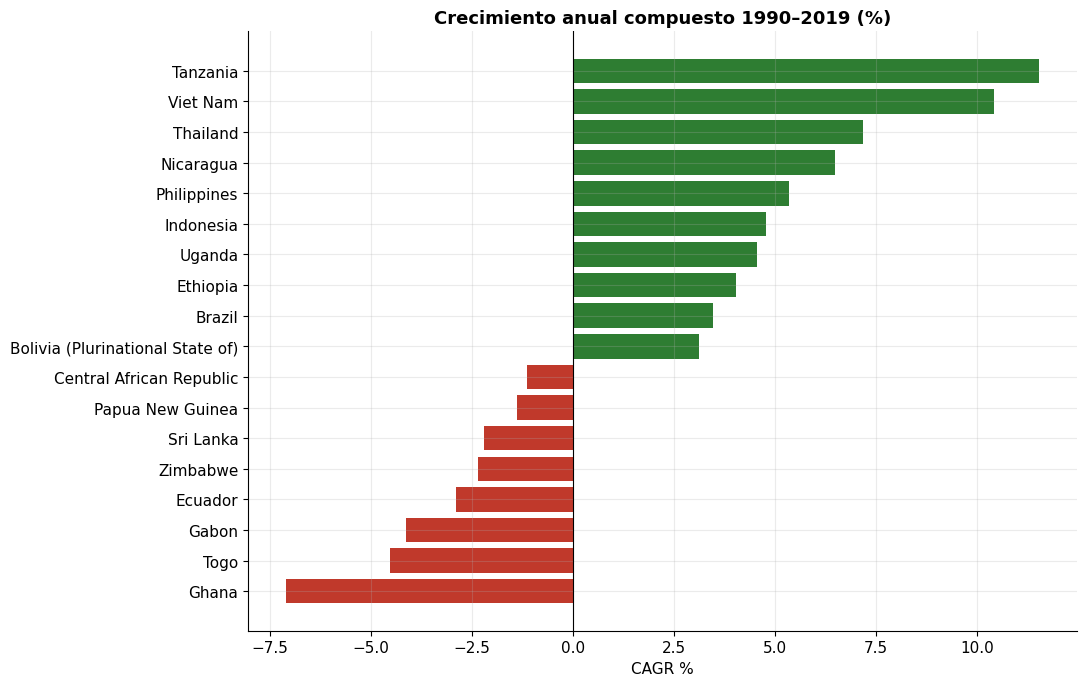

Países en crecimiento: 28 de 40
Países en caída:       10


In [10]:
completos = df.groupby("country").year.agg(["min", "max"])
completos = completos[(completos["min"] == 1990) & (completos["max"] == 2019)].index

# Excluimos las series marcadas como imputadas. Su "crecimiento" es un salto
# entre dos valores constantes, no una trayectoria real: Côte d'Ivoire pasa de
# 3M a 19M de golpe y eso produce un CAGR de 6.6% que no significa nada.
low_var = set(df.loc[df.is_low_variance, "country"].unique())
comparables = [c for c in completos if c not in low_var]
print(f"Series completas 1990-2019: {len(completos)}")
print(f"Comparables tras excluir imputadas: {len(comparables)}")
print(f"Excluidas: {sorted(set(completos) & low_var)}\n")

piv = df[df.country.isin(comparables)].pivot_table(
    index="country", columns="year", values="consumption_kg"
)
cagr = (100 * ((piv[2019] / piv[1990]) ** (1 / 29) - 1)).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
sel = pd.concat([cagr.head(8), cagr.tail(10)])
colors = ["#C0392B" if v < 0 else "#2E7D32" for v in sel.values]
ax.barh(sel.index, sel.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Crecimiento anual compuesto 1990–2019 (%)", weight="bold", fontsize=13)
ax.set_xlabel("CAGR %")
fig.tight_layout()
fig.savefig(FIGS / "03_cagr.png", dpi=150)
plt.show()

print(f"Países en crecimiento: {(cagr > 0).sum()} de {len(cagr)}")
print(f"Países en caída:       {(cagr < 0).sum()}")

Aquí aparece el primer hallazgo accionable de verdad.

**Los mercados que más crecen no son los que más consumen.** Tanzania (11.5%), Vietnam
(10.4%) y Tailandia (7.2%) crecen tres veces más rápido que el mercado mundial, y ninguno
está en el top 3 de volumen. Vietnam multiplicó su consumo doméstico por 17 en 30 años.

En el otro extremo, Ghana (-7.1%), Togo (-4.5%) y Gabón (-4.1%) están en contracción
sostenida. No son mercados objetivo.

## 7. Arábica contra Robusta

El campo `Coffee type` trae mezclas ("Arabica/Robusta"). El orden se interpreta como **indicador de
predominancia**, así que `primary_type` toma el primer elemento.

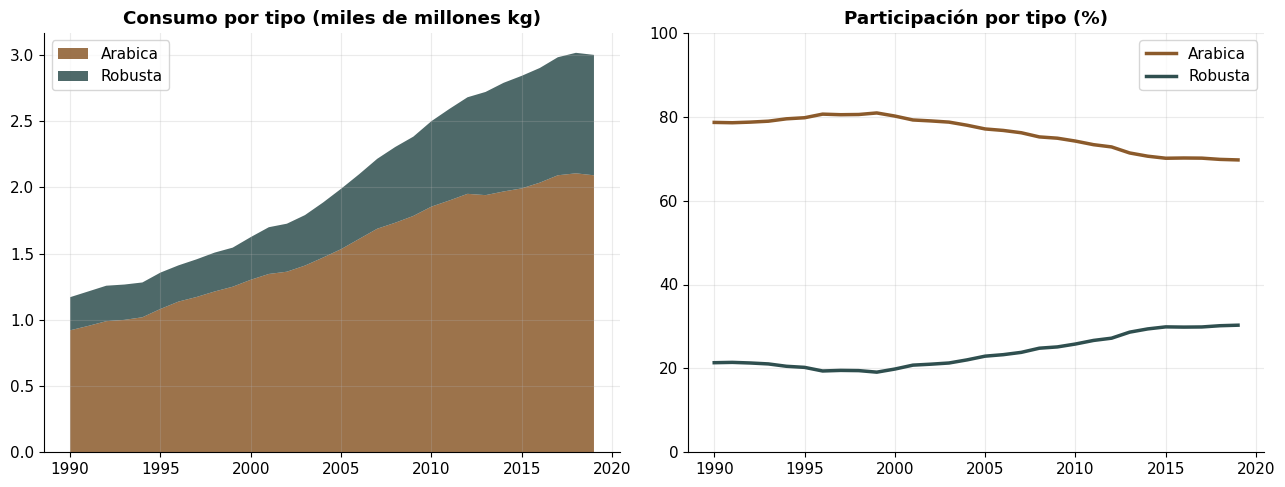

primary_type  Arabica  Robusta
year                          
1990             78.6     21.4
2000             80.2     19.8
2010             74.2     25.8
2019             69.7     30.3


In [11]:
tipo = df.pivot_table(index="year", columns="primary_type",
                      values="consumption_kg", aggfunc="sum")
tipo_pct = 100 * tipo.div(tipo.sum(axis=1), axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.stackplot(tipo.index, tipo.T.values / 1e9,
              labels=tipo.columns, colors=["#8B5A2B", "#2F4F4F"], alpha=0.85)
ax1.legend(loc="upper left")
ax1.set_title("Consumo por tipo (miles de millones kg)", weight="bold")

for col, color in zip(tipo_pct.columns, ["#8B5A2B", "#2F4F4F"]):
    ax2.plot(tipo_pct.index, tipo_pct[col], lw=2.5, label=col, color=color)
ax2.legend()
ax2.set_title("Participación por tipo (%)", weight="bold")
ax2.set_ylim(0, 100)

fig.tight_layout()
fig.savefig(FIGS / "04_tipo_cafe.png", dpi=150)
plt.show()

print(tipo_pct.loc[[1990, 2000, 2010, 2019]].round(1))

## 8. Agrupando países por *forma* de trayectoria

Hasta aquí la comparación ha sido de niveles y tasas. Pero para segmentar mercados lo que
importa es la **forma** de la curva: quién despega, quién se estanca, quién cae.

Cada serie se normaliza a base 100 en su primer año (así el tamaño no domina) y se agrupa
con K-Means. Esto responde la pregunta de negocio *"¿qué mercados se comportan igual?"*.

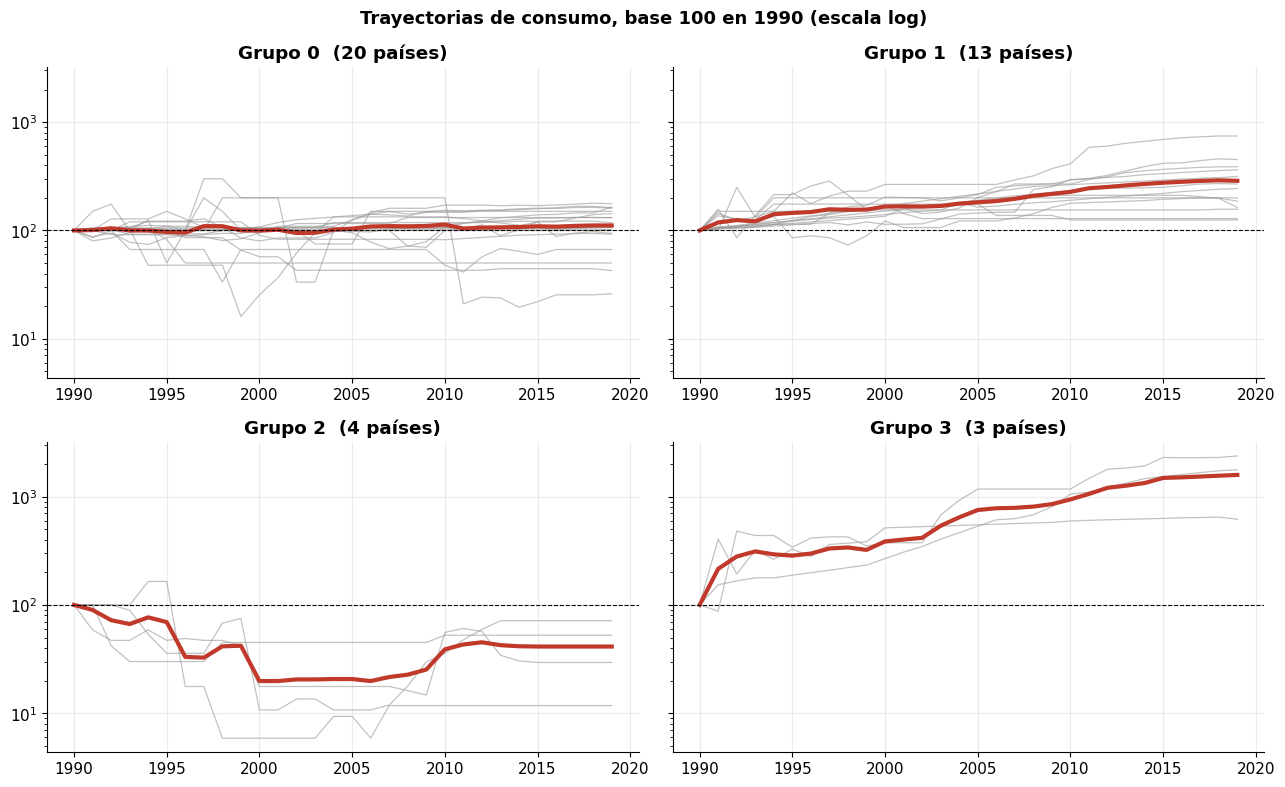

Grupo 0 (CAGR medio   0.0%): Angola, Burundi, Cameroon, Colombia, Costa Rica, Cuba, Dominican Republic, Ecuador, El Salvador, Guatemala, India, Kenya, Madagascar, Mexico, Panama, Papua New Guinea, Peru, Rwanda, Togo, Zimbabwe
Grupo 1 (CAGR medio   3.2%): Bolivia (Plurinational State of), Brazil, Ethiopia, Guinea, Haiti, Honduras, Indonesia, Jamaica, Philippines, Thailand, Trinidad & Tobago, Uganda, Venezuela
Grupo 2 (CAGR medio  -3.6%): Central African Republic, Gabon, Ghana, Sri Lanka
Grupo 3 (CAGR medio   9.5%): Nicaragua, Tanzania, Viet Nam


In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Solo países con serie completa y sin marca de baja varianza
validos = df[df.country.isin(completos) & ~df.is_low_variance]
mat = validos.pivot_table(index="country", columns="year", values="consumption_kg")
base100 = mat.div(mat[1990], axis=0) * 100

X = StandardScaler().fit_transform(np.log(base100.values))
km = KMeans(n_clusters=4, n_init=20, random_state=42).fit(X)
base100["cluster"] = km.labels_

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for k, ax in enumerate(axes.ravel()):
    grupo = base100[base100.cluster == k].drop(columns="cluster")
    for pais in grupo.index:
        ax.plot(grupo.columns, grupo.loc[pais], color="#999", lw=0.9, alpha=0.6)
    ax.plot(grupo.columns, grupo.mean(), color="#C0392B", lw=3)
    ax.axhline(100, ls="--", color="black", lw=0.8)
    ax.set_yscale("log")
    ax.set_title(f"Grupo {k}  ({len(grupo)} países)", weight="bold")

fig.suptitle("Trayectorias de consumo, base 100 en 1990 (escala log)",
             fontsize=13, weight="bold")
fig.tight_layout()
fig.savefig(FIGS / "05_clusters.png", dpi=150)
plt.show()

for k in sorted(base100.cluster.unique()):
    paises = base100[base100.cluster == k].index.tolist()
    crec = cagr[paises].mean()
    print(f"Grupo {k} (CAGR medio {crec:5.1f}%): {', '.join(paises)}")

Los cuatro grupos tienen una lectura de negocio inmediata:

| Grupo | CAGR medio | Países | Lectura |
|---|---|---|---|
| **Despegue** | +9.5% | Vietnam, Tanzania, Nicaragua | Mercados que se multiplicaron. Prioridad de expansión. |
| **Crecimiento sostenido** | +3.2% | Brasil, Etiopía, Indonesia, Filipinas, Tailandia, Uganda, Honduras… | El motor del mercado. Aquí está el volumen *y* el crecimiento. |
| **Estancados** | 0.0% | Colombia, México, India, Perú, Guatemala, Kenia, Costa Rica… | Consumo plano en 30 años. Mercados maduros o saturados. |
| **Contracción** | −3.6% | Ghana, Gabón, Rep. Centroafricana, Sri Lanka | En retirada sostenida. Descartar. |

Dos observaciones que valen para la estrategia de una exportadora:

- **El grupo de crecimiento sostenido es el más valioso**, porque combina escala con
  expansión. Brasil e Indonesia no solo son grandes: siguen creciendo por encima del 3%.
- **Colombia aparece en el grupo estancado.** Su consumo doméstico lleva tres décadas
  plano pese a ser productor de primer nivel. Es un dato incómodo y, justamente por eso,
  interesante de señalar.

Nota metodológica: el clustering se hace sobre el logaritmo de la serie en base 100, de
modo que agrupa por *forma* de la trayectoria y no por tamaño del país. Sin esa
normalización, Brasil quedaría solo en su propio grupo por pura escala.

## 9. Hallazgos y hacia dónde va la solución

**Sobre el dato**

1. Las unidades son kilogramos, no tazas. El enunciado tiene un error de especificación.
2. Los ceros codifican ausencia de reporte, no consumo nulo. Tratarlos como ceros
   reales distorsiona tendencias y rompe cualquier pronóstico (Zambia es el caso claro).
3. Nueve países tienen series imputadas con constantes; deben excluirse de la evaluación
   para no inflar las métricas.
4. `Total_domestic_consumption` es la suma de los años: fuga de información si se usa
   como variable predictora.

**Sobre el negocio**

5. El mercado crece 3.3% anual de forma sostenida, sin quiebres estructurales.
6. Está extremadamente concentrado: 7 países son el 80%, Brasil solo es el 44%.
7. El crecimiento y el volumen están desacoplados. Tanzania, Vietnam y Tailandia crecen
   3x más rápido que el mundo sin estar entre los mayores consumidores.
8. Hay mercados en contracción sostenida (Ghana, Togo, Gabón) que conviene descartar.

**Restricción que condiciona todo el modelado**

Cada país tiene como máximo **30 observaciones anuales**. Eso descarta redes neuronales:
no hay datos suficientes para estimar sus parámetros sin sobreajustar. El plan es comparar
modelos base (naive, drift) contra ETS/ARIMA y un modelo global con rezagos, y dejar que
el backtesting decida. Ver `02_modelado.ipynb`.

**Lo que este dataset NO puede responder**

El enunciado pide *"rangos de precios futuros"*, pero **no hay ninguna variable de precio**.
Esa brecha se aborda explícitamente en el notebook de modelado.